In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1 - Import Libraries

In [2]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set(style="whitegrid")

### 2 - Load Jan 2025 - May 2026 monthly CSV files
 (A minimum of 6 months of dataset)





In [3]:
DATA_PATH = "/content/drive/MyDrive/IDX_Exchange_Su26/data/california/"

# Required months: Jan 2025 - May 2026
months = [
    "202501", "202502", "202503", "202504", "202505", "202506",
    "202507", "202508", "202509", "202510", "202511", "202512",
    "202601", "202602", "202603", "202604", "202605"
]

files = []

for month in months:
    filename = os.path.join(DATA_PATH, f"CRMLSSold{month}.csv")
    if os.path.exists(filename):
        files.append(filename)
    else:
        print(f"Warning: {filename} not found.")

print(f"Number of files loaded: {len(files)}")

for f in files:
    print(os.path.basename(f))

Number of files loaded: 16
CRMLSSold202502.csv
CRMLSSold202503.csv
CRMLSSold202504.csv
CRMLSSold202505.csv
CRMLSSold202506.csv
CRMLSSold202507.csv
CRMLSSold202508.csv
CRMLSSold202509.csv
CRMLSSold202510.csv
CRMLSSold202511.csv
CRMLSSold202512.csv
CRMLSSold202601.csv
CRMLSSold202602.csv
CRMLSSold202603.csv
CRMLSSold202604.csv
CRMLSSold202605.csv


In [4]:
df_list = []

for f in files:
    print(f"Loading {os.path.basename(f)} ...")
    temp = pd.read_csv(f, low_memory=False)
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)

print("\nFinished loading.")
print("Data shape:", df.shape)

df.head()

Loading CRMLSSold202502.csv ...
Loading CRMLSSold202503.csv ...
Loading CRMLSSold202504.csv ...
Loading CRMLSSold202505.csv ...
Loading CRMLSSold202506.csv ...
Loading CRMLSSold202507.csv ...
Loading CRMLSSold202508.csv ...
Loading CRMLSSold202509.csv ...
Loading CRMLSSold202510.csv ...
Loading CRMLSSold202511.csv ...
Loading CRMLSSold202512.csv ...
Loading CRMLSSold202601.csv ...
Loading CRMLSSold202602.csv ...
Loading CRMLSSold202603.csv ...
Loading CRMLSSold202604.csv ...
Loading CRMLSSold202605.csv ...

Finished loading.
Data shape: (345232, 78)


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
0,RanchoSoutheast,RanchoSoutheast,NaN,True,NaN,NaN,NaN,60000.0,526199946,cmark1018@yahoo.com,...,NaN,28000.0,NaN,False,NaN,NaN,92307,0.0,28000.0,NaN
1,InlandValleys,InlandValleys,NaN,False,NaN,NaN,NaN,550000.0,525585060,mozcorona@aol.com,...,NaN,39640.0,NaN,False,NaN,NaN,92553,0.0,39640.0,NaN
2,SanDiego,SanDiego,NaN,False,NaN,NaN,False,880000.0,497696903,lenskab@gmail.com,...,NaN,NaN,NaN,False,2.0,NaN,91942,NaN,NaN,NaN
3,SanDiego,SanDiego,NaN,False,NaN,NaN,False,875000.0,497696407,lenskab@gmail.com,...,NaN,NaN,NaN,False,2.0,NaN,91942,NaN,NaN,NaN
4,SanDiego,SanDiego,NaN,False,NaN,NaN,False,849000.0,486616176,lenskab@gmail.com,...,NaN,NaN,NaN,False,2.0,NaN,91942,NaN,NaN,NaN


Restrict analysis to PropertyType = Residential and PropertySubType = SingleFamilyResidence (per task doc)

In [5]:
df = df[
    (df["PropertyType"] == "Residential") &
    (df["PropertySubType"] == "SingleFamilyResidence")
].copy()

print(df.shape)

(173338, 78)


In [6]:
df.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
2,SanDiego,SanDiego,NaN,False,NaN,NaN,False,880000.0,497696903,lenskab@gmail.com,...,NaN,NaN,NaN,False,2.0,NaN,91942,NaN,NaN,NaN
3,SanDiego,SanDiego,NaN,False,NaN,NaN,False,875000.0,497696407,lenskab@gmail.com,...,NaN,NaN,NaN,False,2.0,NaN,91942,NaN,NaN,NaN
4,SanDiego,SanDiego,NaN,False,NaN,NaN,False,849000.0,486616176,lenskab@gmail.com,...,NaN,NaN,NaN,False,2.0,NaN,91942,NaN,NaN,NaN
15,SouthBay,SouthBay,Carpet,True,NaN,True,False,1100000.0,1108119618,elaine@elainemallon.com,...,NaN,4501.0,4.0,False,2.0,Los Angeles Unified,90731,0.0,4501.0,NaN
16,ContraCosta,ContraCosta,Carpet,NaN,NaN,NaN,False,760000.0,1108119338,sabine.larsen@redfin.com,...,NaN,5040.0,NaN,False,2.0,NaN,94579,NaN,5040.0,NaN


Ensure numeric

### 3 - Explore distributions

### 3.1 - ClosePrice (the target variable)

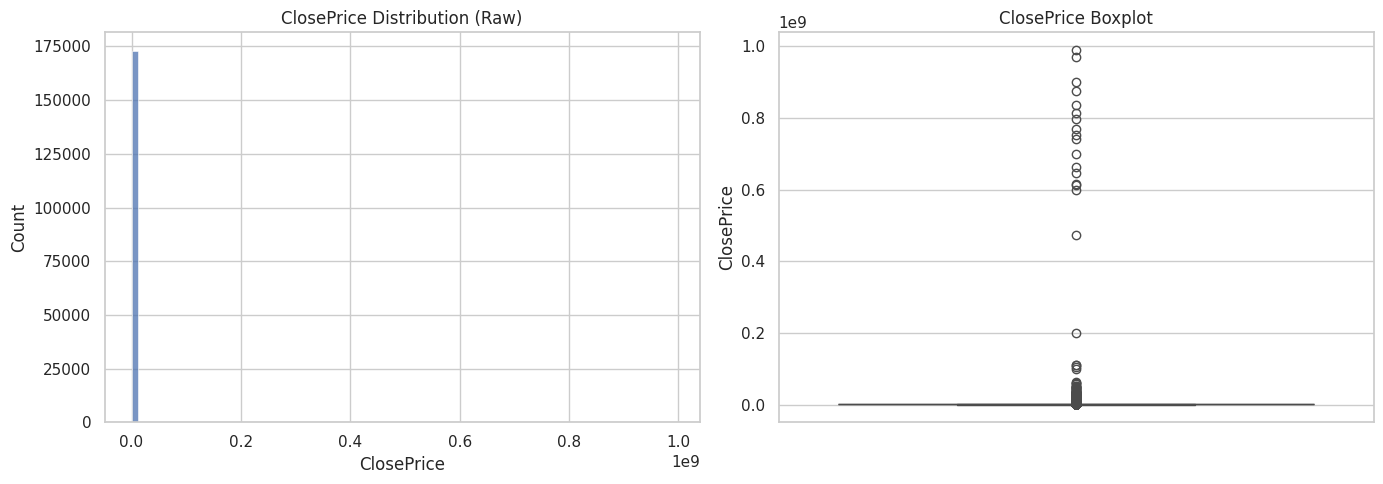

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# raw distribution
sns.histplot(df["ClosePrice"].dropna(), bins=80, ax=axes[0])
axes[0].set_title("ClosePrice Distribution (Raw)")

# boxplot
sns.boxplot(y=df["ClosePrice"].dropna(), ax=axes[1])
axes[1].set_title("ClosePrice Boxplot")

plt.tight_layout()
plt.show()

After removing the top 1% of extreme values, the ClosePrice distribution remains right-skewed, indicating the presence of a long tail of high-end properties in the California housing market.

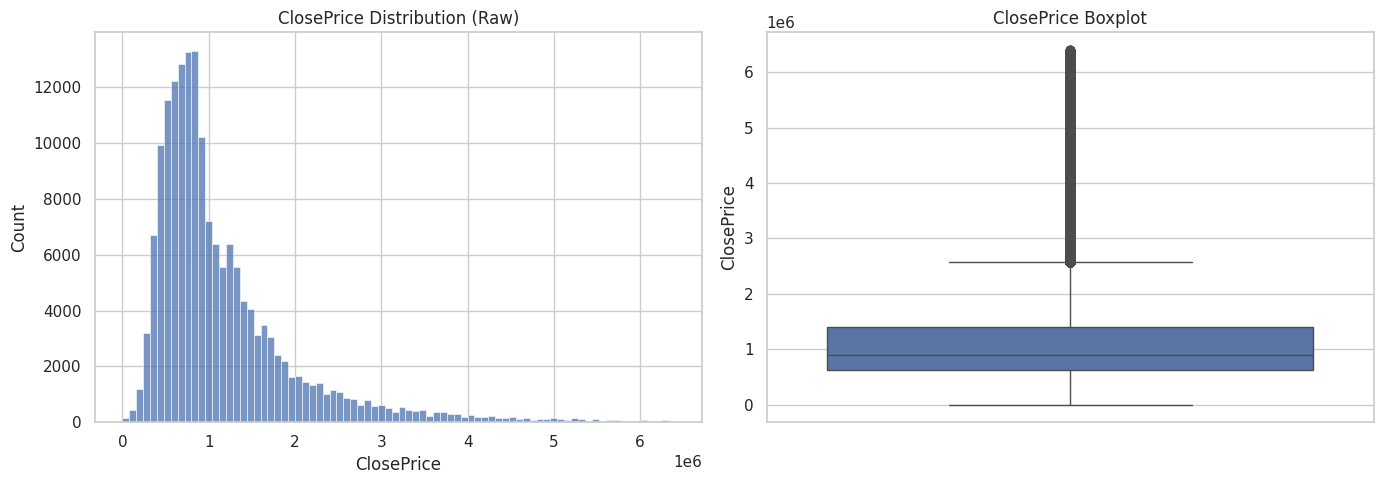

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# raw distribution
df = df[df["ClosePrice"] < df["ClosePrice"].quantile(0.99)]
sns.histplot(df["ClosePrice"].dropna(), bins=80, ax=axes[0])
axes[0].set_title("ClosePrice Distribution (Raw)")

# boxplot
sns.boxplot(y=df["ClosePrice"].dropna(), ax=axes[1])
axes[1].set_title("ClosePrice Boxplot")

plt.tight_layout()
plt.show()

### 3.2 - LivingArea

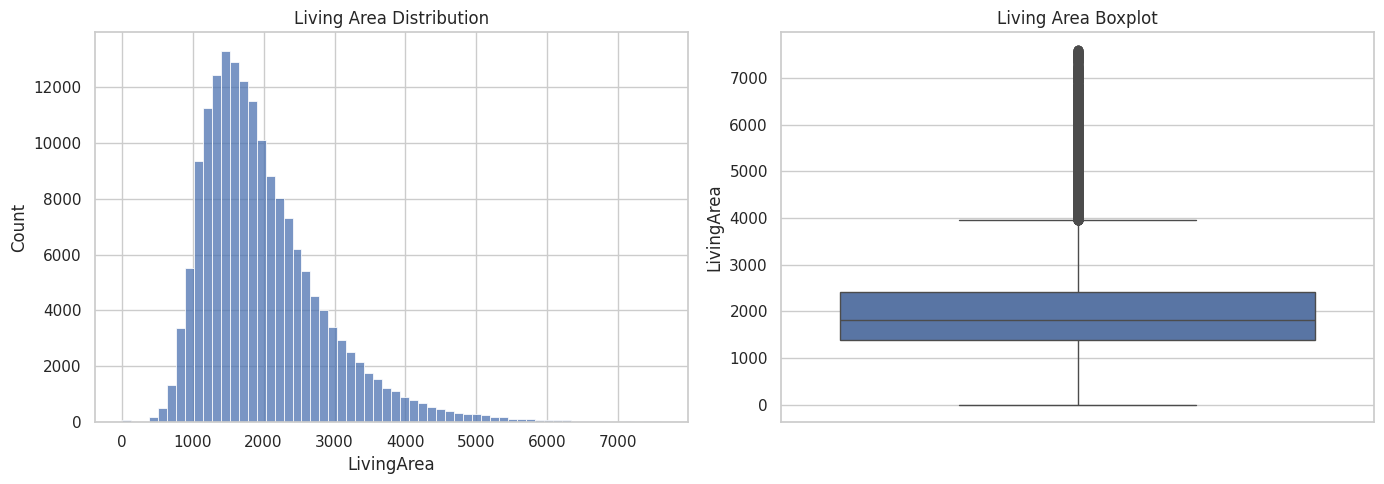

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
df = df[df["LivingArea"] < df["LivingArea"].quantile(0.999)]
sns.histplot(df["LivingArea"].dropna(), bins=60, ax=axes[0])
axes[0].set_title("Living Area Distribution")

sns.boxplot(y=df["LivingArea"].dropna(), ax=axes[1])
axes[1].set_title("Living Area Boxplot")

plt.tight_layout()
plt.show()

### 3.3 - Bedrooms

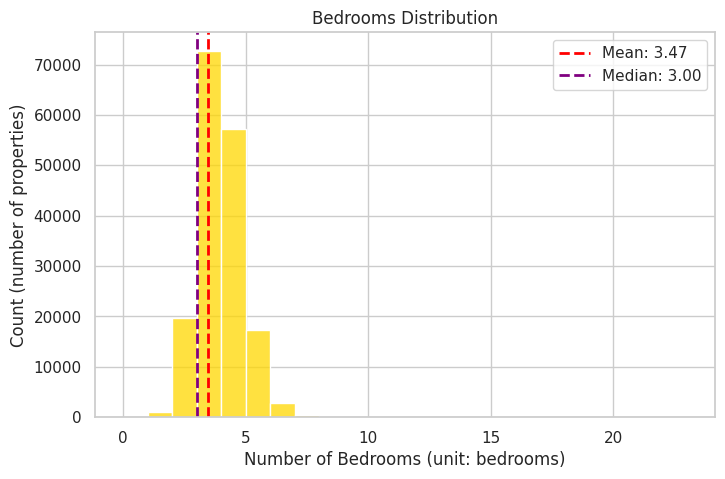

In [10]:
x = df["BedroomsTotal"].dropna()

mean_val = x.mean()
median_val = x.median()

# plot
plt.figure(figsize=(8,5))

sns.histplot(x, bins=range(int(x.min()), int(x.max()) + 2),
             kde=False, color="gold")
# mean line
plt.axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_val:.2f}")
# median line
plt.axvline(median_val, color="purple", linestyle="--", linewidth=2, label=f"Median: {median_val:.2f}")

# labels
plt.title("Bedrooms Distribution")
plt.xlabel("Number of Bedrooms (unit: bedrooms)")
plt.ylabel("Count (number of properties)")

plt.legend()
plt.show()

### 3.4 - Bathrooms

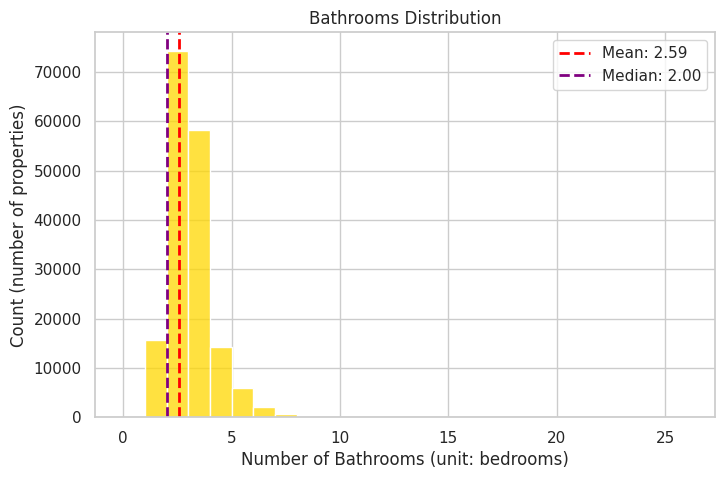

In [11]:
x = df["BathroomsTotalInteger"].dropna()

# clip at 99999%
x = x[x < x.quantile(0.99999)]

mean_val = x.mean()
median_val = x.median()

# plot
plt.figure(figsize=(8,5))

sns.histplot(x, bins=range(int(x.min()), int(x.max()) + 2),
             kde=False, color="gold")
# mean line
plt.axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_val:.2f}")
# median line
plt.axvline(median_val, color="purple", linestyle="--", linewidth=2, label=f"Median: {median_val:.2f}")

# labels
plt.title("Bathrooms Distribution")
plt.xlabel("Number of Bathrooms (unit: bedrooms)")
plt.ylabel("Count (number of properties)")

plt.legend()
plt.show()

3.5 - LotSize

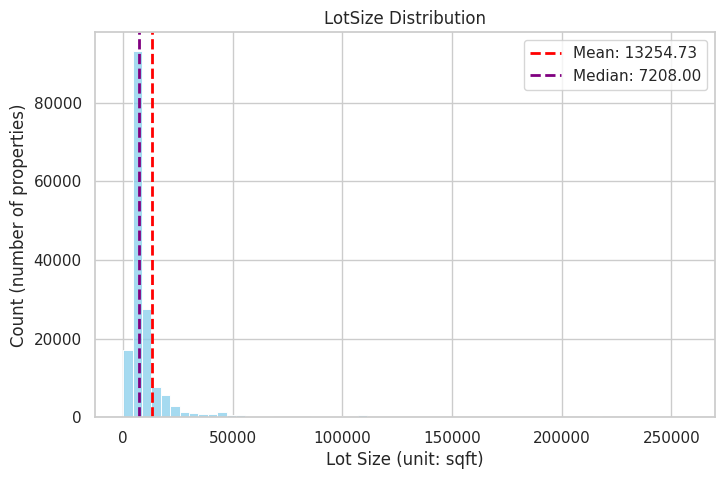

In [12]:
x = df["LotSizeSquareFeet"].dropna()

# clip extreme outliers
x = x[x < x.quantile(0.99)]

mean_val = x.mean()
median_val = x.median()

# plot
plt.figure(figsize=(8,5))

sns.histplot(x, bins=60, kde=False, color="skyblue")

# mean line
plt.axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_val:.2f}")

# median line
plt.axvline(median_val, color="purple", linestyle="--", linewidth=2, label=f"Median: {median_val:.2f}")

# labels
plt.title("LotSize Distribution")
plt.xlabel("Lot Size (unit: sqft)")
plt.ylabel("Count (number of properties)")

plt.legend()
plt.show()